<a href="https://colab.research.google.com/gist/francischisom/4ab8c98490c11b0cf8ca35ab04b2a2ba/ensembling_integrator.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Integrator · Ensemble + Final Comparison

This notebook is the **final integration step** of the NLP pipeline.
It loads pre-computed class probabilities from three base models
(`BiLSTM`, `SVM-BERT`, `BioBERT`), combines them via two ensemble strategies,
and evaluates everything on a held-out test set.

> **Leakage-free stacking:** the meta-learner is trained exclusively on
> *validation* probabilities (which the base models never saw during training)
> and is evaluated on *test* : ensuring no information from the test set
> contaminates the meta-learner.

**Inputs required**
- `probs_{model}_{split}.csv` — softmax probabilities for each base model
- `metrics_{model}.csv` — per-model evaluation metrics
- `gap_{model}.csv` — same-domain vs cross-domain F1 scores
- `ensemble.py` and `eval_utils.py` helper modules



## Setup

Install dependencies , add the project root to `sys.path` so that
`ensemble.py` and `eval_utils.py` can be imported, then define the colour
palette used consistently across all six plots.

In [ ]:
!pip install -q numpy pandas scikit-learn matplotlib
import sys; sys.path.append('.')  # expose local helper modules

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, roc_curve, auc

import eval_utils as ev   # load_and_merge_probabilities, etc.
import ensemble as en     # compare_strategies, soft_vote, stack_probabilities

# Base models whose probability files will be loaded
MODELS = ['bilstm', 'svm_bert', 'biobert']

# Shared colour palette — applied to every plot for visual consistency
NAVY, RED, GREEN, GRAY = '#00002D', '#C44E52', '#2E8B57', '#4C72B0'

##  Load & Merge Probabilities

`ev.load_and_merge_probabilities` reads each model's CSV file, aligns rows
by `uid`, and returns:
- a **DataFrame** with one column per model containing the positive-class
  probability, and
- a **label vector** (`y`) derived from the CSV's `label` column.

We repeat this for both the *validation* split (used to train the
meta-learner) and the *test* split (used for all final evaluations).

In [ ]:
# Load and align probabilities for val and test splits
val_pd,  y_val  = ev.load_and_merge_probabilities(
    [f'probs_{m}_val.csv'  for m in MODELS])  # meta-learner training data
test_pd, y_test = ev.load_and_merge_probabilities(
    [f'probs_{m}_test.csv' for m in MODELS])  # held-out evaluation data

print('Merged models:', list(test_pd), '| test rows:', len(y_test))

Merged models: ['bilstm', 'svm_bert', 'biobert'] | test rows: 451


##  Train Ensemble & Compare Strategies

Two combination strategies are evaluated:

| Strategy | How it works |
|----------|--------------|
| **Soft voting** | Averages the three models' probabilities; no extra training needed |
| **Stacking** | Trains a logistic-regression meta-learner on *val* probabilities, then predicts on *test* |

`en.compare_strategies` returns a results DataFrame and the fitted
meta-learner object (`meta`), which is reused in later cells.

In [ ]:
# Train meta-learner on val, evaluate both strategies on test
ens_results, meta = en.compare_strategies(val_pd, y_val, test_pd, y_test)
ens_results  # display the metrics table inline

,strategy,accuracy,precision,recall,f1,f1_macro,roc_auc
0,Stacking (LR meta-learner),0.982262,0.985240,0.98524,0.985240,0.981509,0.998237
1,Soft voting (mean proba),0.982262,0.981685,0.98893,0.985294,0.981474,0.998319


In [ ]:
# Select the strategy with the highest macro-F1 on test
best_strategy = (
    ens_results
    .sort_values('f1_macro', ascending=False)
    .iloc[0]['strategy']
)

# Compute the winning ensemble's test probabilities.
# These are reused by the ROC overlay (Plot 5) and confusion matrix (Plot 4).
if best_strategy.startswith('Stacking'):
    test_matrix, _ = en.stack_probabilities(test_pd)
    ens_proba = meta.predict_proba(test_matrix)[:, 1]  # positive-class prob
else:
    ens_proba = en.soft_vote(test_pd)  # weighted or simple average

ens_pred = (ens_proba >= 0.5).astype(int)  # hard labels at 0.5 threshold
print('Chosen ensemble strategy:', best_strategy)

Chosen ensemble strategy: Stacking (LR meta-learner)


## Plot· Stacking vs Soft-Voting

Side-by-side bars compare the two strategies across three metrics
(binary F1, macro-F1, ROC-AUC) on the test set.
This justifies which ensemble method is carried forward as the final model.

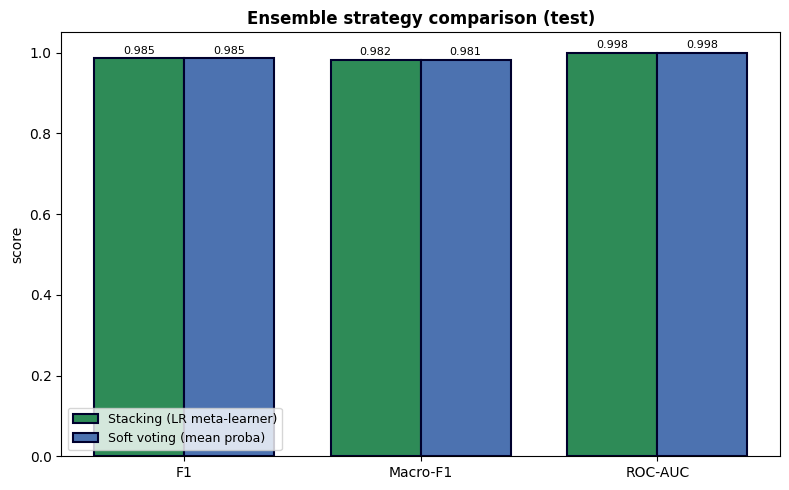

In [ ]:
metrics = ['f1', 'f1_macro', 'roc_auc']
x = np.arange(len(metrics))
w = 0.38  # bar width

fig, ax = plt.subplots(figsize=(8, 5))

# One bar group per strategy; offset left/right by half a bar-width
for i, (_, row) in enumerate(ens_results.iterrows()):
    vals = [row[m] for m in metrics]
    ax.bar(x + (i - 0.5) * w, vals, width=w,
           label=row['strategy'],
           color=[GREEN, GRAY][i], edgecolor=NAVY, linewidth=1.5)

ax.set_xticks(x)
ax.set_xticklabels(['F1', 'Macro-F1', 'ROC-AUC'])
ax.set_ylim(0, 1.05)
ax.set_ylabel('score')
ax.set_title('Ensemble strategy comparison (test)', fontweight='bold')
ax.legend(fontsize=9)

# Annotate each bar with its numeric value
for p in ax.patches:
    ax.annotate(f'{p.get_height():.3f}',
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=8, xytext=(0, 2),
                textcoords='offset points')

plt.tight_layout()
plt.savefig('ens_03_strategies.png', dpi=150)
plt.show()

##  Final Comparison Table

Concatenate the per-model metric CSVs and append a row for the best
ensemble strategy, then sort by macro-F1 descending.
The result is saved to `final_model_comparison.csv` for use in the report.

In [ ]:
# Load individual model metrics and combine into one table
rows = [pd.read_csv(f'metrics_{m}.csv') for m in MODELS]
comparison = pd.concat(rows, ignore_index=True)

# Append the best ensemble's metrics as an extra row
best = ens_results.sort_values('f1_macro', ascending=False).iloc[0]
comparison = pd.concat([
    comparison,
    pd.DataFrame([{
        'model':     f"Ensemble ({best['strategy']})",
        'accuracy':  best['accuracy'],
        'precision': best['precision'],
        'recall':    best['recall'],
        'f1':        best['f1'],
        'f1_macro':  best['f1_macro'],
        'roc_auc':   best.get('roc_auc', float('nan')),
    }])
], ignore_index=True)

# Sort best-to-worst and persist
comparison = comparison.sort_values('f1_macro', ascending=False)
comparison.to_csv('final_model_comparison.csv', index=False)
comparison

,model,accuracy,precision,recall,f1,f1_macro,roc_auc
1,SVM-BERT,0.982262,0.985240,0.98524,0.985240,0.981509,0.992148
3,Ensemble (Stacking (LR meta-learner)),0.982262,0.985240,0.98524,0.985240,0.981509,0.998237
2,BioBERT,0.980044,0.981618,0.98524,0.983425,0.979178,0.994916
0,Bi-LSTM,0.977827,0.978022,0.98524,0.981618,0.976842,0.996781


## Plot. Final Model Comparison (Macro-F1)

Macro-F1 is the primary metric because the ADE detection task has
imbalanced classes; it weights each class equally regardless of support.
The ensemble bar is highlighted in red to make it easy to locate.

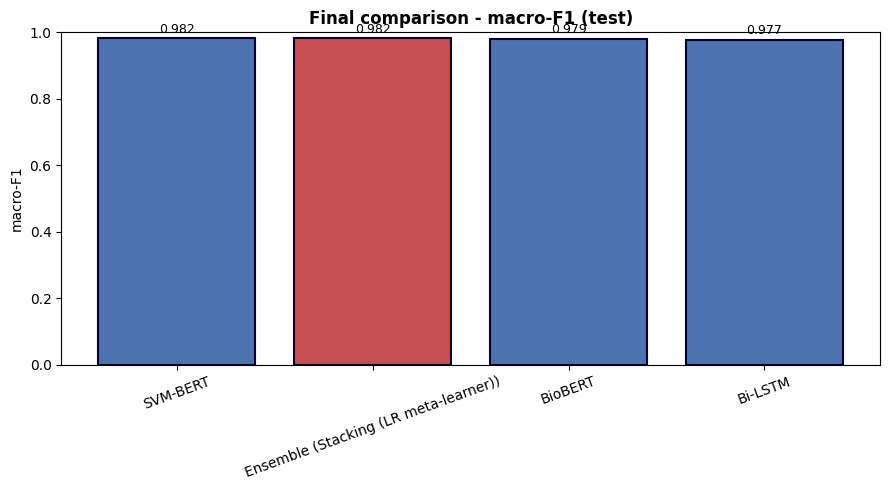

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))

# Highlight the ensemble bar in red; individual models are gray
colors = [RED if 'Ensemble' in m else GRAY for m in comparison['model']]
ax.bar(comparison['model'], comparison['f1_macro'],
       color=colors, edgecolor=NAVY, linewidth=1.5)

ax.set_title('Final comparison - macro-F1 (test)', fontweight='bold')
ax.set_ylabel('macro-F1')
ax.set_ylim(0, 1)
ax.tick_params(axis='x', rotation=20)

# Value labels on top of each bar
for p in ax.patches:
    ax.annotate(f'{p.get_height():.3f}',
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=9, xytext=(0, 2),
                textcoords='offset points')

plt.tight_layout()
plt.savefig('ens_01_comparison_f1.png', dpi=150)
plt.show()

## Plot · ROC-AUC Overlay

Overlaying all three base models and the ensemble on a single ROC plot
lets us compare *discrimination ability* independent of the 0.5
classification threshold.
A higher AUC means the model ranks positive examples above negatives
more reliably across all possible thresholds.

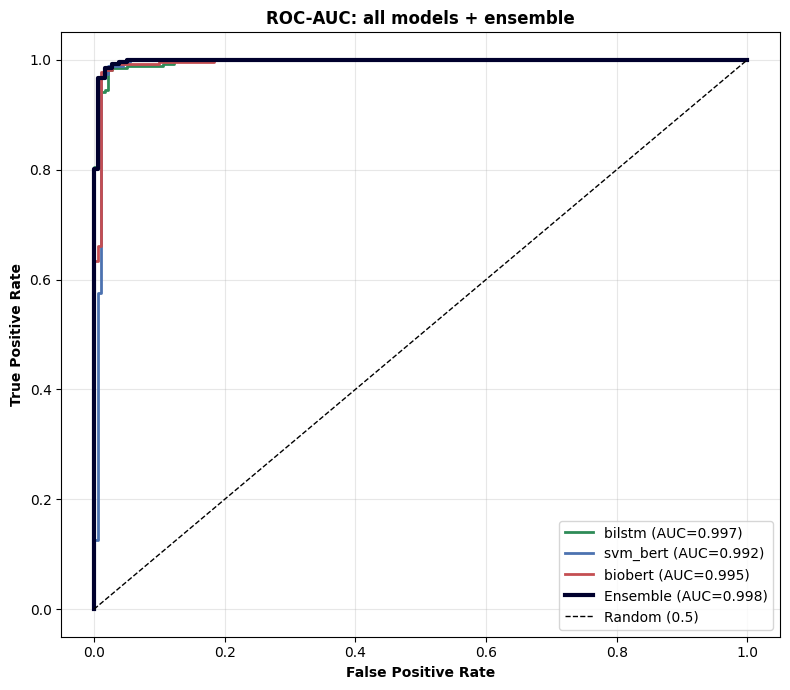

In [ ]:
fig, ax = plt.subplots(figsize=(8, 7))
palette = {'bilstm': GREEN, 'svm_bert': GRAY, 'biobert': RED}

# Plot each base model's ROC curve using its test probabilities
for m in MODELS:
    fpr, tpr, _ = roc_curve(y_test, test_pd[m])
    ax.plot(fpr, tpr, lw=2, color=palette.get(m),
            label=f'{m} (AUC={auc(fpr, tpr):.3f})')

# Overlay the ensemble curve with a thicker line
fpr, tpr, _ = roc_curve(y_test, ens_proba)
ax.plot(fpr, tpr, lw=3, color=NAVY,
        label=f'Ensemble (AUC={auc(fpr, tpr):.3f})')

# Diagonal reference line representing a random classifier (AUC = 0.5)
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random (0.5)')

ax.set_xlabel('False Positive Rate', fontweight='bold')
ax.set_ylabel('True Positive Rate', fontweight='bold')
ax.set_title('ROC-AUC: all models + ensemble', fontweight='bold')
ax.legend(loc='lower right')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('ens_05_roc.png', dpi=150)
plt.show()

## Plot  Confusion Matrix of the Final Ensemble

The confusion matrix shows the raw counts of true positives, false
positives, false negatives, and true negatives.
For ADE detection, **false negatives** (missed ADEs) are typically more
costly than false positives, so we print precision and recall explicitly.

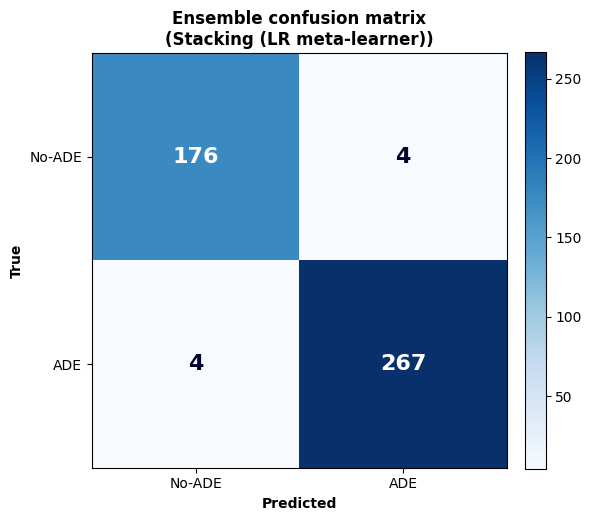

TP=267  FP=4  FN=4  TN=176
Precision=0.985  Recall=0.985


In [ ]:
cm = confusion_matrix(y_test, ens_pred)

fig, ax = plt.subplots(figsize=(6, 5.5))
im = ax.imshow(cm, cmap='Blues')

ax.set_xticks([0, 1]); ax.set_xticklabels(['No-ADE', 'ADE'])
ax.set_yticks([0, 1]); ax.set_yticklabels(['No-ADE', 'ADE'])
ax.set_xlabel('Predicted', fontweight='bold')
ax.set_ylabel('True', fontweight='bold')
ax.set_title(f'Ensemble confusion matrix\n({best_strategy})', fontweight='bold')

# Flip text colour to white for dark cells so numbers stay readable
thresh = cm.max() / 2
for i in range(2):
    for j in range(2):
        ax.text(j, i, format(cm[i, j], 'd'),
                ha='center', va='center',
                color='white' if cm[i, j] > thresh else NAVY,
                fontsize=16, fontweight='bold')

fig.colorbar(im, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.savefig('ens_04_confusion.png', dpi=150)
plt.show()

# Print derived metrics directly from the matrix
tn, fp, fn, tp = cm.ravel()
print(f'TP={tp}  FP={fp}  FN={fn}  TN={tn}')
print(f'Precision={tp/(tp+fp):.3f}  Recall={tp/(tp+fn):.3f}')

## Plot · Meta-Learner Weights

The stacking meta-learner (logistic regression) assigns a coefficient to
each base model's probability.
A **larger positive coefficient** means the meta-learner gives that model's
output more weight in the final decision; a negative coefficient means it
actively discounts that model.
This plot reveals which base model the ensemble trusts most.

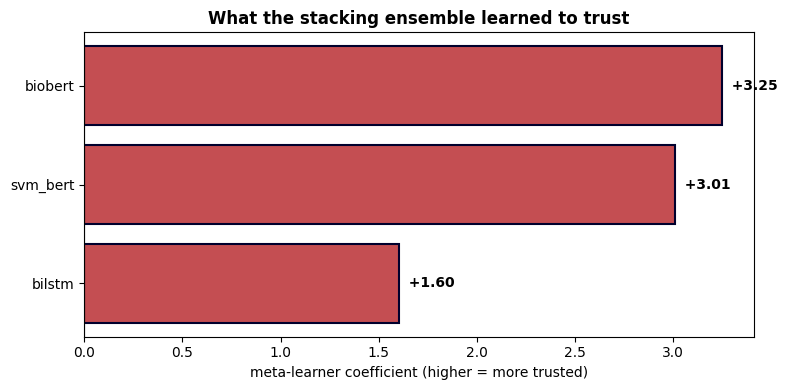

In [ ]:
# Retrieve feature names by re-stacking the val probabilities
_, names = en.stack_probabilities(val_pd)
weights = meta.coef_[0]  # coefficients from the logistic-regression meta-learner

# Sort ascending so the horizontal bar chart reads smallest-to-largest
order   = np.argsort(weights)
names_o = [names[i] for i in order]
w_o     = weights[order]

fig, ax = plt.subplots(figsize=(8, 4))

# Positive weights in red, negative (distrusted) weights in gray
ax.barh(names_o, w_o,
        color=[RED if v > 0 else GRAY for v in w_o],
        edgecolor=NAVY, linewidth=1.5)
ax.axvline(0, color='#444', lw=0.8)  # zero-weight reference line

ax.set_xlabel('meta-learner coefficient (higher = more trusted)')
ax.set_title('What the stacking ensemble learned to trust', fontweight='bold')

# Annotate each bar with its coefficient value
for i, v in enumerate(w_o):
    ax.text(v, i, f'  {v:+.2f}', va='center', fontweight='bold')

plt.tight_layout()
plt.savefig('ens_06_meta_weights.png', dpi=150)
plt.show()

## Plot · Cross-Domain Generalisation Gap

Objective 3 of the project requires testing whether models trained on
formal clinical text (e.g. MEDLINE abstracts) generalise to informal
social-media language (e.g. tweets).

Each `gap_{model}.csv` file contains two F1 scores per model:
- `f1_standard` — evaluated on same-domain test data
- `f1_cross` — evaluated on out-of-domain (Formal → Informal) test data

A large gap between the two bars signals poor generalisation.

   model  f1_standard  f1_cross  degradation_pct
 Bi-LSTM       0.9816    0.9760              0.6
SVM-BERT       0.9852    0.9943             -0.9
 BioBERT       0.9834    0.9894             -0.6


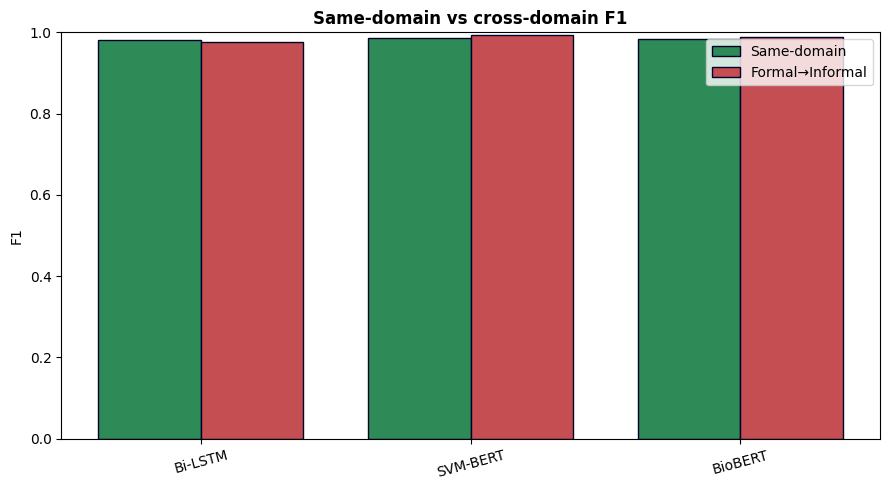

In [ ]:
# Load cross-domain gap data for all models and combine
gap = pd.concat(
    [pd.read_csv(f'gap_{m}.csv') for m in MODELS],
    ignore_index=True
)
gap.to_csv('generalisation_gap_all_models.csv', index=False)
print(gap.to_string(index=False))

x = range(len(gap))
w = 0.38  # bar width

fig, ax = plt.subplots(figsize=(9, 5))

# Same-domain bars on the left, cross-domain on the right of each model group
ax.bar([i - w / 2 for i in x], gap['f1_standard'], width=w,
       label='Same-domain', color=GREEN, edgecolor=NAVY)
ax.bar([i + w / 2 for i in x], gap['f1_cross'],    width=w,
       label='Formal→Informal', color=RED, edgecolor=NAVY)

ax.set_xticks(list(x))
ax.set_xticklabels(gap['model'], rotation=15)
ax.set_title('Same-domain vs cross-domain F1', fontweight='bold')
ax.set_ylabel('F1')
ax.set_ylim(0, 1)
ax.legend()

plt.tight_layout()
plt.savefig('ens_02_gap.png', dpi=150)
plt.show()